# Smyth et al. (1969) Drug–Drug Interaction LD₅₀ Dataset Construction

This notebook reconstructs and processes a drug–drug interaction (DDI) toxicity dataset based on the classic study:

“An exploration of joint toxic action: Twenty-seven industrial chemicals intubated in rats in all possible pairs” (Smyth et al., 1969)

The goal is to transform experimental tabular data into a machine learning–ready dataset for predicting mixture LD₅₀ values.

Key Objectives

- Digitize and structure mixture toxicity data from the paper

- Compute observed mixture LD₅₀ values from reported ratios

- Integrate chemical structures (SMILES)

- Convert units from ml/kg → mg/kg using densities


Author links open overlay panelHenry F. Smyth Jr., Carrol S. Weil,
Jean S. West
, Charles P. Carpenter

https://www.sciencedirect.com/science/article/abs/pii/0041008X6990115X?via%3Dihub

In [6]:
import csv

# Chemical names in the order they appear in Table B (rows and columns)
chemicals = [
    "Acetone", "Acetonitrile", "Acetophenone", "Acrylonitrile", "Aniline",
    "Butyl Cellosolve", "Butyl ether", "Carbon tetrachloride", "Diethanolamine",
    "Dioxane", "Ethyl acetate", "Ethyl acrylate", "Ethyl alcohol", "Ethylene glycol",
    "Formalin", "Isophorone", "Morpholine", "Nitrobenzene", "Phenyl Cellosolve",
    "PEG 400", "Propylene glycol", "Propylene oxide", "Tergitol XD",
    "Tetrachloroethylene", "Toluene", "Ucon 50HB260", "Ucon LB250"
]

# Single‑drug LD50 (ml/kg) from Table A in the same order
ld50_values = [
    11.16,  # Acetone
    8.27,   # Acetonitrile
    2.48,   # Acetophenone
    0.14,   # Acrylonitrile
    0.71,   # Aniline
    2.38,   # Butyl Cellosolve
    13.6,   # Butyl ether
    3.08,   # Carbon tetrachloride
    0.80,   # Diethanolamine
    6.47,   # Dioxane
    10.9,   # Ethyl acetate
    0.83,   # Ethyl acrylate
    19.7,   # Ethyl alcohol
    6.46,   # Ethylene glycol
    1.85,   # Formalin
    2.28,   # Isophorone
    1.62,   # Morpholine
    0.50,   # Nitrobenzene
    3.28,   # Phenyl Cellosolve
    40.1,   # PEG 400
    44.3,   # Propylene glycol
    0.73,   # Propylene oxide
    5.66,   # Tergitol XD
    8.00,   # Tetrachloroethylene
    7.80,   # Toluene
    5.33,   # Ucon 50HB260
    10.1    # Ucon LB250
]

# SMILES strings (SMILES were retrieved from PubChem by searching the chemical name)
smiles_dict = {
    "Acetone": "CC(=O)C",                     # PubChem (CID 180)
    "Acetonitrile": "CC#N",                   # PubChem (CID 6342)
    "Acetophenone": "CC(=O)c1ccccc1",         # PubChem (CID 7410)
    "Acrylonitrile": "C=CC#N",                # PubChem (CID 7855)
    "Aniline": "Nc1ccccc1",                   # PubChem (CID 6115)
    "Butyl Cellosolve": "CCCCOCCO",           # 2‑butoxyethanol, PubChem (CID 8133)
    "Butyl ether": "CCCCOCCCC",               # Dibutyl ether, PubChem (CID 8909)
    "Carbon tetrachloride": "ClC(Cl)(Cl)Cl",  # PubChem (CID 5943)
    "Diethanolamine": "OCCNCCO",              # PubChem (CID 8113)
    "Dioxane": "C1COCCO1",                    # 1,4‑dioxane, PubChem (CID 31275)
    "Ethyl acetate": "CCOC(=O)C",             # PubChem (CID 8857)
    "Ethyl acrylate": "CCOC(=O)C=C",          # PubChem (CID 8821)
    "Ethyl alcohol": "CCO",                   # Ethanol, PubChem (CID 702)
    "Ethylene glycol": "OCCO",                # PubChem (CID 174)
    "Formalin": "C=O",                        # formaldehyde
    "Isophorone": "CC1=CC(=O)CC(C)(C)C1",     # PubChem (CID 6544)
    "Morpholine": "C1COCCN1",                 # PubChem (CID 8083)
    "Nitrobenzene": "[O-][N+](=O)c1ccccc1",   # PubChem (CID 7416)
    "Phenyl Cellosolve": "c1ccccc1OCCO",      # 2‑phenoxyethanol, PubChem (CID 7632)
    "PEG 400": "OCCOCCOCCOCCOCCOCCOCCOCCO",   # Approximate linear chain with 8 ethylene oxide units (average MW 400). PEG 400 is a polymer, so a representative SMILES was used.
    "Propylene glycol": "CC(O)CO",            # PubChem (CID 1030)
    "Propylene oxide": "CC1CO1",              # PubChem (CID 6378)
    "Tergitol XD": "CCCCCCCCCCCCCOCCOCCOCCO", # Approximate SMILES for a nonyl/decyl ethoxylate surfactant
    "Tetrachloroethylene": "ClC(Cl)=C(Cl)Cl", # PubChem (CID 31373)
    "Toluene": "Cc1ccccc1",                   # PubChem (CID 1140)
    "Ucon 50HB260": "CC(C)OCC(C)OCC(C)O",     # Approximate SMILES for a polyalkylene glycol
    "Ucon LB250": "CC(C)OCC(C)OCC(C)O"        # Same approximate SMILES as Ucon 50HB260 (both are similar polyalkylene glycols)
}

# Ratio matrix (lower triangular) extracted from Table B.
# For each row i (starting from 0 = Acetone), the list contains ratios for columns j > i.
# The order of columns for each row is the same as the global chemical list, skipping the row chemical.
ratios = [
    # Acetone (i=0): 26 values for columns 1..26
    [3.63, 1.19, 1.17, 0.87, 1.08, 0.95, 1.28, 0.98, 1.16, 0.91, 1.08, 0.86, 0.45, 1.81, 1.62, 0.77, 1.47, 0.65, 0.99, 0.88, 0.44, 0.83, 1.83, 1.33, 0.50, 0.53],
    # Acetonitrile (i=1): 25 values for columns 2..26
    [3.31, 1.17, 0.81, 1.06, 1.00, 0.64, 0.74, 3.15, 0.67, 1.05, 0.85, 0.86, 1.46, 1.30, 0.96, 0.85, 0.75, 2.27, 0.55, 1.54, 2.02, 2.33, 1.73, 1.12, 1.12],
    # Acetophenone (i=2): 24 values for columns 3..26
    [0.49, 0.76, 1.49, 1.29, 2.22, 0.58, 1.06, 1.43, 0.85, 1.57, 0.78, 2.15, 0.51, 1.01, 0.98, 0.66, 0.62, 0.57, 0.50, 0.87, 3.28, 1.84, 0.63, 0.45],
    # Acrylonitrile (i=3): 23 values for columns 4..26
    [0.74, 1.12, 0.80, 1.12, 0.23, 0.73, 1.27, 0.86, 1.00, 1.08, 0.55, 1.04, 0.45, 0.82, 1.08, 0.88, 0.76, 0.50, 1.56, 1.47, 1.40, 0.96, 1.00],
    # Aniline (i=4): 22 values for columns 5..26
    [0.70, 0.97, 1.02, 0.67, 0.90, 0.83, 0.54, 0.60, 0.71, 0.31, 0.58, 1.32, 1.32, 0.75, 1.12, 0.71, 0.60, 0.78, 0.92, 0.75, 0.89, 0.62],
    # Butyl Cellosolve (i=5): 21 values for columns 6..26
    [1.39, 1.70, 0.64, 0.79, 1.10, 0.89, 1.21, 1.12, 1.35, 0.77, 1.10, 0.85, 0.50, 1.49, 1.30, 0.64, 0.73, 1.55, 1.39, 0.88, 0.92],
    # Butyl ether (i=6): 20 values for columns 7..26
    [1.67, 0.92, 0.83, 0.90, 0.83, 0.74, 0.71, 2.32, 0.74, 0.92, 1.28, 1.06, 0.80, 0.67, 0.56, 1.18, 2.76, 0.59, 1.34, 0.53],
    # Carbon tetrachloride (i=7): 19 values for columns 8..26
    [1.17, 1.21, 0.41, 0.78, 1.09, 0.56, 0.46, 1.97, 2.22, 1.47, 1.11, 1.16, 0.78, 1.08, 0.57, 1.74, 1.51, 0.83, 0.62],
    # Diethanolamine (i=8): 18 values for columns 9..26
    [0.88, 1.02, 0.28, 1.44, 0.71, 1.83, 0.71, 0.93, 0.70, 0.76, 1.29, 0.89, 0.74, 0.71, 0.72, 0.94, 0.80, 0.89],
    # Dioxane (i=9): 17 values for columns 10..26
    [0.70, 1.10, 0.61, 0.54, 1.41, 0.88, 0.69, 1.39, 0.86, 0.54, 0.51, 0.70, 0.60, 2.83, 0.90, 0.40, 0.70],
    # Ethyl acetate (i=10): 16 values for columns 11..26
    [0.98, 0.72, 0.58, 2.70, 1.14, 0.76, 0.97, 0.75, 0.71, 1.15, 1.22, 0.39, 1.31, 0.53, 0.87, 0.72],
    # Ethyl acrylate (i=11): 15 values for columns 12..26
    [1.20, 0.80, 1.00, 0.84, None, 1.07, 0.78, 1.25, 1.13, 0.84, 1.03, 1.06, 0.80, 1.19, 0.53],
    # Ethyl alcohol (i=12): 14 values for columns 13..26
    [0.24, 1.78, 1.29, 1.18, 0.97, 0.88, 0.66, 0.97, 0.37, 1.12, 1.52, 1.56, 0.96, 0.62],
    # Ethylene glycol (i=13): 13 values for columns 14..26
    [1.02, 0.77, 0.47, 1.07, 0.54, 0.82, 0.43, 0.54, 0.73, 0.75, 0.99, 0.69, 0.62],
    # Formalin (i=14): 12 values for columns 15..26
    [0.85, 0.93, 1.20, 1.10, 0.70, 1.38, 0.63, 1.90, 1.38, 2.02, 0.84, 1.36],
    # Isophorone (i=15): 11 values for columns 16..26
    [1.16, 0.62, 0.46, 0.90, 1.51, 0.41, 0.65, 1.35, 0.80, 0.50, 0.50],
    # Morpholine (i=16): 10 values for columns 17..26
    [0.86, 0.56, 0.63, 0.93, 0.43, 1.18, 2.51, 5.09, 1.18, 1.15],
    # Nitrobenzene (i=17): 9 values for columns 18..26
    [1.12, 0.72, 1.00, 0.87, 0.92, 0.82, 0.78, 0.99, 1.26],
    # Phenyl Cellosolve (i=18): 8 values for columns 19..26
    [0.69, 0.87, 0.46, 0.52, 1.61, 1.33, 0.75, 0.83],
    # PEG 400 (i=19): 7 values for columns 20..26
    [0.99, 0.70, 0.54, 2.70, 1.45, 1.41, 0.94],
    # Propylene glycol (i=20): 6 values for columns 21..26
    [0.38, 0.83, 1.69, 0.84, 0.72, 0.91],
    # Propylene oxide (i=21): 5 values for columns 22..26
    [0.40, 0.66, 0.72, 0.64, 0.48],
    # Tergitol XD (i=22): 4 values for columns 23..26
    [0.67, 0.72, 1.12, 1.22],
    # Tetrachloroethylene (i=23): 3 values for columns 24..26
    [1.73, 1.33, 1.17],
    # Toluene (i=24): 2 values for columns 25..26
    [0.64, 0.94],
    # Ucon 50HB260 (i=25): 1 value for column 26
    [1.06],
    # Ucon LB250 (i=26): no further values (already last)
    []
]

# Build a full symmetric ratio matrix for easy lookup
n = len(chemicals)
ratio_matrix = [[None]*n for _ in range(n)]
for i in range(n):
    row = ratios[i]
    col_idx = i+1
    for val in row:
        if col_idx < n:
            ratio_matrix[i][col_idx] = val
            ratio_matrix[col_idx][i] = val  # symmetric
        col_idx += 1

# Generate CSV
with open('ddi_ld50_smyth.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['DrugA', 'DrugB', 'SMILES_A', 'SMILES_B',
                     'LD50_A_ml/kg', 'LD50_B_ml/kg', 'Mixture_LD50_ml/kg', 'Unit'])

    for i in range(n):
        for j in range(i+1, n):
            ratio = ratio_matrix[i][j]
            if ratio is None:
                continue  # skip missing (e.g., violent reaction)
            ld50_a = ld50_values[i]
            ld50_b = ld50_values[j]
            # Predicted additive LD50 using harmonic mean for equal volumes
            pred_additive = 2.0 / (1.0/ld50_a + 1.0/ld50_b)
            observed = pred_additive / ratio
            writer.writerow([
                chemicals[i], chemicals[j],
                smiles_dict[chemicals[i]], smiles_dict[chemicals[j]],
                f"{ld50_a:.2f}", f"{ld50_b:.2f}",
                f"{observed:.3f}", "ml/kg"
            ])

print("CSV file 'ddi_ld50_smyth.csv' generated successfully.")

CSV file 'ddi_ld50_smyth.csv' generated successfully.


# Determining the observed LD50 of a mixture based on the paper. (Verify the extracted data)

Formulas


1. Predicted Additive LD50 (Harmonic Mean Formula)


For a 1:1 mixture by volume:

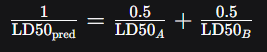


Or rearranged:

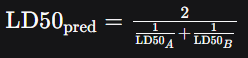


2. Observed Mixture LD50


From the ratio given in Table 1:

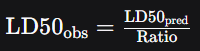

Where the Ratio is the value from Table 1 (Predicted/Observed).

---
**Example Calculation**


Let's calculate the observed mixture LD50 for the pair Acetone + Acetonitrile.


Step 1: Find individual LD50 values from Table 3

- Acetone median LD50 = 11.16 ml/kg

- Acetonitrile median LD50 = 8.27 ml/kg


Step 2: Calculate predicted additive LD50

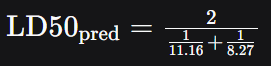


First, calculate the reciprocals:

1/11.16 = 0.0896

1/8.27 = 0.1209

Sum = 0.0896 + 0.1209 = 0.2105

Now divide:

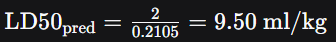

Step 3: Find the ratio from Table 1

For Acetone + Acetonitrile, Table 1 shows: 3.63

**LD50 obs = 9.50007 / 3.63 = 2.617 ml/kg**

Step 4: Calculate observed mixture LD50



Interpretation: The observed LD50 (2.617 ml/kg) is lower than the predicted additive LD50 (9.50 ml/kg), indicating that this mixture is more toxic than additive (Ratio > 1.0 means observed < predicted).

---
**Another Example (More than additive)**


For Morpholine + Toluene (Ratio = 5.09 from Table 1):


Step 1: Individual LD50 values:

- Morpholine = 1.62 ml/kg

- Toluene = 7.80 ml/kg


Step 2: Calculate predicted additive:

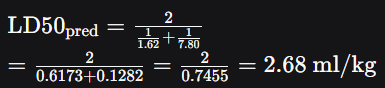

Step 3: Apply ratio:

LD50 obs = 2.68 / 5.09 = 0.527 ml/kg

Interpretation: The observed LD50 (0.527 ml/kg) is much lower than predicted (2.68 ml/kg), indicating synergistic/more than additive toxicity (Ratio > 1.0 means observed < predicted).



In [7]:
import pandas as pd

df = pd.read_csv('ddi_ld50_smyth.csv')
df.head()

,DrugA,DrugB,SMILES_A,SMILES_B,LD50_A_ml/kg,LD50_B_ml/kg,Mixture_LD50_ml/kg,Unit
0,Acetone,Acetonitrile,CC(=O)C,CC#N,11.16,8.27,2.617,ml/kg
1,Acetone,Acetophenone,CC(=O)C,CC(=O)c1ccccc1,11.16,2.48,3.410,ml/kg
2,Acetone,Acrylonitrile,CC(=O)C,C=CC#N,11.16,0.14,0.236,ml/kg
3,Acetone,Aniline,CC(=O)C,Nc1ccccc1,11.16,0.71,1.535,ml/kg
4,Acetone,Butyl Cellosolve,CC(=O)C,CCCCOCCO,11.16,2.38,3.633,ml/kg


# ml/kg to mg/kg

In [8]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('ddi_ld50_smyth.csv')

# Density dictionary (g/ml) for each chemical
density = {
    'Acetone': 0.785,
    'Acetonitrile': 0.786,
    'Acetophenone': 1.028,
    'Acrylonitrile': 0.806,
    'Aniline': 1.022,
    'Butyl Cellosolve': 0.902,      # 2-butoxyethanol
    'Butyl ether': 0.764,           # dibutyl ether
    'Carbon tetrachloride': 1.594,
    'Diethanolamine': 1.097,
    'Dioxane': 1.033,
    'Ethyl acetate': 0.902,
    'Ethyl acrylate': 0.917,
    'Ethyl alcohol': 0.789,          # ethanol
    'Ethylene glycol': 1.113,
    'Formalin': 1.09,                 # 37% formaldehyde solution
    'Isophorone': 0.923,
    'Morpholine': 1.007,
    'Nitrobenzene': 1.199,
    'Phenyl Cellosolve': 1.102,       # 2-phenoxyethanol
    'PEG 400': 1.128,                  # polyethylene glycol 400
    'Propylene glycol': 1.036,
    'Propylene oxide': 0.859,
    'Tergitol XD': 1.06,               # nonylphenol ethoxylate (approximate)
    'Tetrachloroethylene': 1.622,
    'Toluene': 0.867,
    'Ucon 50HB260': 1.05,              # polyalkylene glycol (approximate)
    'Ucon LB250': 1.05                 # polyalkylene glycol (approximate)
}

# Function to convert a single drug's LD50 from ml/kg to mg/kg
def convert_single_ld50(row, drug_letter):
    # drug_letter is 'A' or 'B'
    drug_name = row[f'Drug{drug_letter}']
    ld50_mlkg = row[f'LD50_{drug_letter}_ml/kg']
    if pd.isna(ld50_mlkg) or ld50_mlkg == 0:
        return None
    dens = density.get(drug_name)
    if dens is None:
        raise ValueError(f"Density not defined for {drug_name}")
    return ld50_mlkg * dens * 1000

# Apply conversion to create new columns for single drugs
df['LD50_A_mg/kg'] = df.apply(lambda row: convert_single_ld50(row, 'A'), axis=1)
df['LD50_B_mg/kg'] = df.apply(lambda row: convert_single_ld50(row, 'B'), axis=1)

# Function to estimate mixture density (equal volumes) – arithmetic mean
def mixture_density(row):
    drugA = row['DrugA']
    drugB = row['DrugB']
    densA = density.get(drugA)
    densB = density.get(drugB)
    if densA is None or densB is None:
        raise ValueError(f"Density missing for {drugA} or {drugB}")
    return (densA + densB) / 2

# Apply mixture density and convert mixture LD50
df['Mixture_density_g/ml'] = df.apply(mixture_density, axis=1)
df['Mixture_LD50_mg/kg'] = df['Mixture_LD50_ml/kg'] * df['Mixture_density_g/ml'] * 1000

# Drop the temporary density column if desired (optional)
# df = df.drop(columns=['Mixture_density_g/ml'])

# Save the new CSV
df.to_csv('ddi_ld50_smyth_mgkg.csv', index=False)

print("Conversion complete. New file saved as 'ddi_ld50_smyth_mgkg.csv'.")

Conversion complete. New file saved as 'ddi_ld50_smyth_mgkg.csv'.


In [9]:
df.head()

,DrugA,DrugB,SMILES_A,SMILES_B,LD50_A_ml/kg,LD50_B_ml/kg,Mixture_LD50_ml/kg,Unit,LD50_A_mg/kg,LD50_B_mg/kg,Mixture_density_g/ml,Mixture_LD50_mg/kg
0,Acetone,Acetonitrile,CC(=O)C,CC#N,11.16,8.27,2.617,ml/kg,8760.6,6500.22,0.7855,2055.6535
1,Acetone,Acetophenone,CC(=O)C,CC(=O)c1ccccc1,11.16,2.48,3.410,ml/kg,8760.6,2549.44,0.9065,3091.1650
2,Acetone,Acrylonitrile,CC(=O)C,C=CC#N,11.16,0.14,0.236,ml/kg,8760.6,112.84,0.7955,187.7380
3,Acetone,Aniline,CC(=O)C,Nc1ccccc1,11.16,0.71,1.535,ml/kg,8760.6,725.62,0.9035,1386.8725
4,Acetone,Butyl Cellosolve,CC(=O)C,CCCCOCCO,11.16,2.38,3.633,ml/kg,8760.6,2146.76,0.8435,3064.4355


In [10]:
# Drop the original ml/kg columns, the Unit column, and the temporary density column
columns_to_drop = ['LD50_A_ml/kg', 'LD50_B_ml/kg', 'Mixture_LD50_ml/kg', 'Unit', 'Mixture_density_g/ml']
df_clean = df.drop(columns=columns_to_drop)

# Save the cleaned CSV
df_clean.to_csv('ddi_ld50_smyth_final_mgkg.csv', index=False)

print("Conversion complete. Clean file saved as 'ddi_ld50_smyth_final_mgkg.csv'.")
print("Remaining columns:", list(df_clean.columns))

Conversion complete. Clean file saved as 'ddi_ld50_smyth_final_mgkg.csv'.
Remaining columns: ['DrugA', 'DrugB', 'SMILES_A', 'SMILES_B', 'LD50_A_mg/kg', 'LD50_B_mg/kg', 'Mixture_LD50_mg/kg']


Note: 'ddi_ld50_smyth_final_mgkg.csv' download and save to '/content/drive/MyDrive/FYP/IRP/Data/ddi_ld50_smyth/ddi_ld50_smyth_final_mgkg.csv'

In [11]:
df_clean.head()

,DrugA,DrugB,SMILES_A,SMILES_B,LD50_A_mg/kg,LD50_B_mg/kg,Mixture_LD50_mg/kg
0,Acetone,Acetonitrile,CC(=O)C,CC#N,8760.6,6500.22,2055.6535
1,Acetone,Acetophenone,CC(=O)C,CC(=O)c1ccccc1,8760.6,2549.44,3091.1650
2,Acetone,Acrylonitrile,CC(=O)C,C=CC#N,8760.6,112.84,187.7380
3,Acetone,Aniline,CC(=O)C,Nc1ccccc1,8760.6,725.62,1386.8725
4,Acetone,Butyl Cellosolve,CC(=O)C,CCCCOCCO,8760.6,2146.76,3064.4355
